# Amazon Data Analysis & Review Score Prediction

## Spark Setup

In [1]:
import pyspark
from pyspark.sql import SparkSession
import matplotlib.pyplot as plt
import seaborn as sns

Matplotlib created a temporary cache directory at /scratch/bguo3/job_46969815/matplotlib-ioulttzn because the default path (/home/jovyan/.cache/matplotlib) is not a writable directory; it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


In [2]:
# Initializing our spark
"""
Formula == 
Executor instances = Total Cores - 1
Executor memory = (Total Memory - Driver Memory) / Executor Instances

Executor instances = 32 − 1 = 31
Executor memory = (128 − 2) / 31 ≈ 4.06GB → 4GB per executor

NOTE:
The execution size was the driving factor for this set based on previous experience \
working with social media analysis.
Given the 54GB size of the Amazon dataset, this configuration provides:

-High parallelism (31 concurrent tasks)
-Sufficient executor memory to reduce shuffle spill
-Balanced memory distribution to prevent executor OOM during aggregations

The 4GB executor size was chosen to provide adequate memory headroom for groupBy and \
aggregation operations without creating excessively large JVM heaps, \
which can increase garbage collection overhead.
"""
# spark = (
#     SparkSession.builder
#     .appName('amazon_set')
#     .config('spark.driver.memory', '2g')
#     .config('spark.executor.instances', '31')
#     .config('spark.executor.memory', '4g')
#     .config('spark.executor.cores', '1')
#     .getOrCreate()
# )
spark = (
    SparkSession.builder
    .appName('amazon_set')
    .config('spark.driver.memory', '24g')
    .config('spark.executor.instances', '31')
    .config('spark.executor.memory', '16g')
    .config('spark.executor.cores', '9')
    .getOrCreate()
)

In [3]:
import requests
import pandas as pd # RECALL we're going to use spark not pandas

# Get the active Spark Context and URL
sc = spark.sparkContext
url = f"{sc.uiWebUrl}/api/v1/applications/{sc.applicationId}/executors"

# Fetch the executor data from the API
response = requests.get(url)
executors = response.json()

# Format into a readable DataFrame
df = pd.DataFrame(executors)[['id', 'totalCores', 'maxMemory', 'activeTasks', 'isActive']]
df['maxMemory_GB'] = (df['maxMemory'] / (1024**3)).round(2)
df

,id,totalCores,maxMemory,activeTasks,isActive,maxMemory_GB
0,driver,32,15273138585,0,True,14.22


In [4]:
from pyspark.sql.types import (
    StructType, StructField,
    StringType, IntegerType
)


## Data Collection

In [5]:
import kagglehub
from pyspark.sql import functions as F
from pyspark.sql.types import StructType, StructField, StringType, IntegerType

# Download dataset (cached by kagglehub)
base_dir = kagglehub.dataset_download('cynthiarempel/amazon-us-customer-reviews-dataset')
print('Downloaded to:', base_dir)

# Schema (recommended)
schema = StructType([
    StructField('marketplace', StringType(), True),
    StructField('customer_id', StringType(), True),
    StructField('review_id', StringType(), True),
    StructField('product_id', StringType(), True),
    StructField('product_parent', StringType(), True),
    StructField('product_title', StringType(), True),
    StructField('product_category', StringType(), True),
    StructField('star_rating', IntegerType(), True),
    StructField('helpful_votes', IntegerType(), True),
    StructField('total_votes', IntegerType(), True),
    StructField('vine', StringType(), True),
    StructField('verified_purchase', StringType(), True),
    StructField('review_headline', StringType(), True),
    StructField('review_body', StringType(), True),
    StructField('review_date', StringType(), True),
])

pattern = f'file:{base_dir}/amazon_reviews_us_*_v*.tsv'

reviews_df = (
    spark.read
        .option('header', 'true')
        .option('sep', '\t')
        .schema(schema)
        .csv(pattern)
        .withColumn('source_file', F.input_file_name())
        .withColumn('category', F.regexp_extract('source_file', r'amazon_reviews_us_([^/]+?)_v', 1))
        .filter(F.col('category') != 'multilingual')
        .drop('source_file')
)

Downloaded to: /home/bguo3/.cache/kagglehub/datasets/cynthiarempel/amazon-us-customer-reviews-dataset/versions/9


In [6]:
reviews_df.select('category', 'star_rating', 'product_id').show(10, truncate=False)

+--------+-----------+----------+
|category|star_rating|product_id|
+--------+-----------+----------+
|Apparel |4          |B01KL6O72Y|
|Apparel |5          |B01ID3ZS5W|
|Apparel |5          |B01I497BGY|
|Apparel |5          |B01HDXFZK6|
|Apparel |5          |B01G6MBEBY|
|Apparel |5          |B01FWRXN0Y|
|Apparel |5          |B01EXNH1HE|
|Apparel |4          |B01E7OL09O|
|Apparel |5          |B01DXHX81O|
|Apparel |3          |B01DDULIJK|
+--------+-----------+----------+
only showing top 10 rows



In [7]:
print('Partitions:', reviews_df.rdd.getNumPartitions())

Partitions: 384


## Exploratory Data Analysis

### Overall Inspection

In [8]:
# Let's... see how big this data is!
# Row count
row_counts = reviews_df.count()
print(f"Total row counts: {row_counts} rows")

# Memory count
sample_fraction = 0.001
sample_size_in_bytes = (
    reviews_df
    .sample(fraction=sample_fraction)
    .toPandas()
    .memory_usage(deep=True)
    .sum()
) 
total_size_in_gb = sample_size_in_bytes / (sample_fraction * (1024**3))
print(f"Total estimated size: {total_size_in_gb:.2f} GB")

Total row counts: 102899354 rows
Total estimated size: 120.23 GB


In [9]:
# Check the schema
reviews_df.printSchema()

root
 |-- marketplace: string (nullable = true)
 |-- customer_id: string (nullable = true)
 |-- review_id: string (nullable = true)
 |-- product_id: string (nullable = true)
 |-- product_parent: string (nullable = true)
 |-- product_title: string (nullable = true)
 |-- product_category: string (nullable = true)
 |-- star_rating: integer (nullable = true)
 |-- helpful_votes: integer (nullable = true)
 |-- total_votes: integer (nullable = true)
 |-- vine: string (nullable = true)
 |-- verified_purchase: string (nullable = true)
 |-- review_headline: string (nullable = true)
 |-- review_body: string (nullable = true)
 |-- review_date: string (nullable = true)
 |-- category: string (nullable = false)



| Column | Description |
|---|---|
| **marketplace** | Country/region the review was posted on (e.g. US, UK) |
| **product_id** | Unique identifier for the product (ASIN on Amazon) |
| **product_parent** | Groups product variants (e.g. same book in hardcover/paperback) under one parent ID |
| **product_title** | Name/title of the product |
| **product_category** | Category the product belongs to (e.g. Wireless, Sports, Beauty) |
| **customer_id** | Unique identifier for the reviewer |
| **review_id** | Unique identifier for the review itself |
| **star_rating** | Rating given by the customer (1–5 stars) |
| **review_headline** | Short title/summary of the review |
| **review_body** | Full text of the review |
| **review_date** | Date the review was posted |
| **helpful_votes** | Number of people who found the review helpful |
| **total_votes** | Total number of people who voted on the review (helpful or not) |
| **vine** | Whether the reviewer is part of Amazon's Vine program (`Y`/`N`) |
| **verified_purchase** | Whether the reviewer actually bought the product on Amazon (`Y`/`N`) |
| **category** | Broader/redundant category label, possibly added during data processing |


In [10]:
# Check the Spark details
print('master:', spark.sparkContext.master)
print('partitions:', reviews_df.rdd.getNumPartitions())

master: local[*]
partitions: 384


In [11]:
# Check the summary statistics
reviews_df.describe().toPandas()

,summary,marketplace,customer_id,review_id,product_id,product_parent,product_title,product_category,star_rating,helpful_votes,total_votes,vine,verified_purchase,review_headline,review_body,review_date,category
0,count,102899354,102899354,102899354,102899354,102899354,102899354,102897602,102897561,102897561,102897561,102897561,102897561,102897322,102887488,102891724,102899354
1,mean,None,2.833727936438536E7,None,1.4258244766243584E9,5.003337964375594E8,NaN,None,4.162648160338805,1.9020360161889551,2.536008594022943,None,None,NaN,Infinity,None,None
2,stddev,None,1.5723536662173402E7,None,1.9362264182029324E9,2.88790890535497E8,NaN,None,1.286758530247085,20.772935235587735,22.44830756465268,None,None,NaN,NaN,None,None
3,min,US,100000,R100007TERQ36I,0000000078,100000041,Fine in Time,2002-08-07,1,0,0,N,N,\tAll was good :)\t2015-02-02,__________________________________<br />I mad...,1995-06-24,Apparel
4,max,US,9999996,RZZZZYOFYZ829,BT00IU6O8K,999999945,🌴 Vacation On The Beach,"\\""Red Spring Blossom Flowers with Yellow Bees...",5,47524,48362,Y,Y,🤹🏽‍♂️🎤Great product. Practice makes perfect. D...,🛅🚑🚚🚏🚙🚈🚘🚈🚘🚏🚘🚙🚎🚎🚈🎶🎶🎷🏁🏁🎷🎓👚👚🎓👢🎩👡👒👡👒👡🎩👚🎒🚹🔡🔚🔚📵🅾🔜📴🔜🆎🔜...,2015-08-31,Wireless


### Product Category

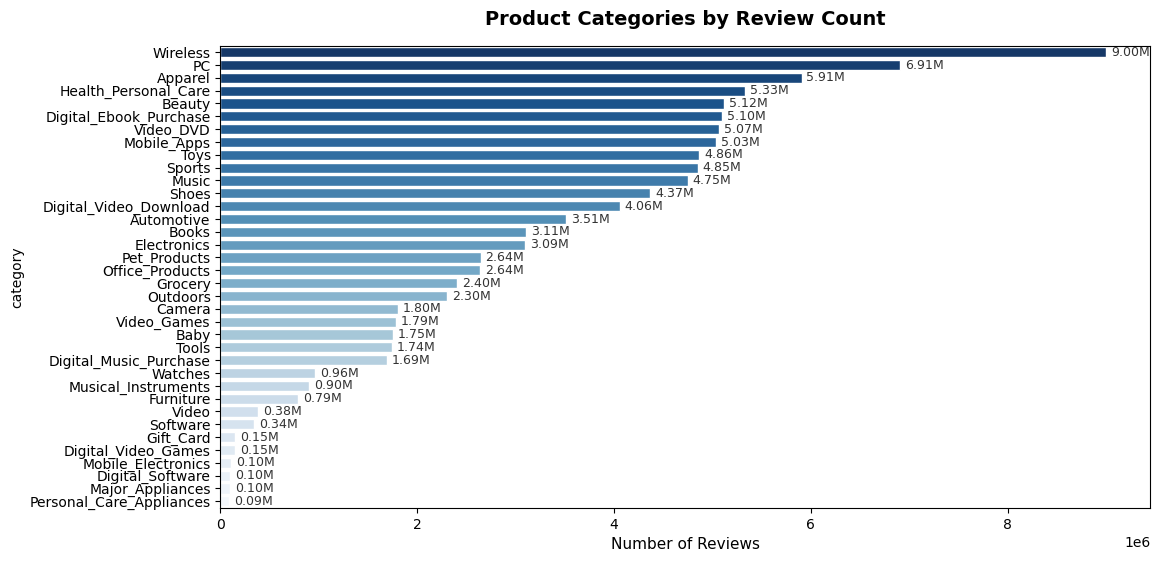

In [12]:
# Product category distribution

# --- Data ---
product_dist_df = (
    reviews_df
    # Groupby + Agg(count) + Sort
    .groupBy('category')
    .count()
    .orderBy(F.desc('count'))
)

# --- Plot ---
# Convert to Pandas
product_dist_pd = product_dist_df.toPandas()
# Plot
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(
    data=product_dist_pd,
    x='count',
    y='category',
    hue='category',
    legend=False,
    palette='Blues_r',
    edgecolor='white',
    ax=ax
)
# Edit text on categories
for bar in ax.patches:
    w = bar.get_width()
    ax.text(
        w + 50_000, bar.get_y() + bar.get_height() / 2,
        f'{w/1_000_000:.2f}M',
        va='center', ha='left', fontsize=9, color='#333'
    )
# Annotation
ax.set_xlabel('Number of Reviews', fontsize=11)
ax.set_title(
    'Product Categories by Review Count', 
    fontsize=14, 
    fontweight='bold', 
    pad=15
)
plt.show()

In [13]:
# Product category distribution

# Let's play with the data. What are our most popular products?
top_categories = (
    reviews_df
    .groupBy('product_category')
    .agg(F.count('*').alias('review_count'))
    .orderBy(F.desc('review_count'))
    .limit(10)
)
top_categories.show(truncate=False)

+----------------------+------------+
|product_category      |review_count|
+----------------------+------------+
|Wireless              |9001881     |
|PC                    |6908551     |
|Apparel               |5906322     |
|Health & Personal Care|5331215     |
|Beauty                |5115452     |
|Digital_Ebook_Purchase|5101676     |
|Video DVD             |5069136     |
|Mobile_Apps           |5033376     |
|Toys                  |4864243     |
|Sports                |4849563     |
+----------------------+------------+



**Observations**: Categories are highly unbalanced, there are a lot of technology/electronic-related categories, but they both have the highest and lowest count. It would be an issue if the prediction is about category classification.

### Sport Analysis

In [14]:
# Let's focus on a sports-specific data frame for plotting 
# since sports have the lowest review counts among the most popular categories

# We'll scale this up for our own needs with all the data in the future
sports_df = (
    reviews_df
    .filter(F.lower(F.col('product_category')) == 'sports')
)

# materialize cache (important)
sports_df.cache()

# How many sports products do we have?
row_counts = sports_df.count()
print(f"Total row counts: {row_counts} rows")

# How much does sports_df occupy in memory?
sample_fraction = 0.001
sample_size_in_bytes = (
    sports_df
    .sample(fraction=sample_fraction)
    .toPandas()
    .memory_usage(deep=True)
    .sum()
) 
total_size_in_gb = sample_size_in_bytes / (sample_fraction * (1024**3))
print(f"Total estimated size: {total_size_in_gb:.2f} GB")

Total row counts: 4849563 rows
Total estimated size: 5.31 GB


**Observations**: 
- We can see that sports_df occupied about 5 GB of data, which is why setting the memory of 4GB per executor does not work
- We already know that the review_df has (total row: 102899354, total size: 118.75 GB), since sports_df row counts is around 4% of the review_df row counts, so it's reasonable to directly estimate that sports_df memory is around 4% of review_df's

In [15]:
# How about if we check for the unique sports products by product_id

distinct_sports_products = (
    sports_df
    .select('product_id')
    .distinct()
    .count()
)
print(f'Distinct Sports products: {distinct_sports_products}')

Distinct Sports products: 1046129


+----------+-----+
|product_id|count|
+----------+-----+
|B001HBHNHE|7405 |
|7245456313|3693 |
|B00FX0S4DC|3051 |
|B000UVVX28|3006 |
|B002QZ1RS6|2922 |
|B003TJH3LI|2823 |
|B005M1P85O|2786 |
|B001EJMS6K|2560 |
|B00178CS4K|2299 |
|B00B1N0R6C|2278 |
+----------+-----+



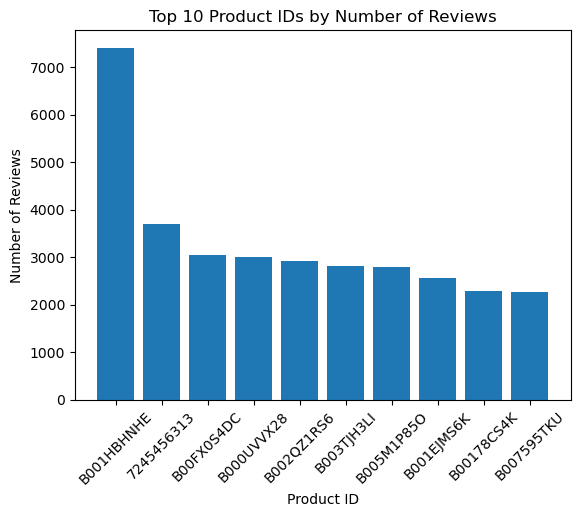

In [16]:
# --- Data ---
top10_products = (
    sports_df
    .groupBy('product_id')
    .count()
    .orderBy(F.desc('count'))
    .limit(10)
)
top10_products.show(truncate=False)
top10_pd = top10_products.toPandas()

# --- Plot ----
plt.figure()
plt.bar(top10_pd['product_id'], top10_pd['count'])
plt.xticks(rotation = 45)
plt.xlabel('Product ID')
plt.ylabel('Number of Reviews')
plt.title('Top 10 Product IDs by Number of Reviews')
plt.show()

In [17]:
# Discretize star rating 
# (As it was defined to be an integer, this just ensures it works as expected)

from pyspark.sql import functions as F
sports_df_clean = (
    sports_df
    .withColumn("star_rating_int", F.expr("try_cast(star_rating as int)"))
    .filter(F.col("star_rating_int").isNotNull())
)

In [ ]:
# This code took too long to generate result, it show very left skewed for rating and right skewed for helpful

# # We want to check the distribution of quantitative columns for skewness

# # Star rating dist
# # --- Data ---
# dist_pd = (
#     sports_df_clean
#     .select(["star_rating_int", "helpful_votes"])
#     # 5% of data
#     .sample(fraction=0.05)
#     .toPandas()
# )

# # --- Plot ---
# fig, axes = plt.subplots(1, 2, figsize=(16, 5))
# plots = [
#     ("star_rating_int",   "Average Rating"),
#     ("helpful_votes", "Helpful Votes"),
# ]
# for ax, (col, title) in zip(axes, plots):
#     sns.barplot(
#         dist_pd[col],
#         ax=ax
#     )
#     ax.set_title(
#         "Distribution of " + title, 
#         fontsize=13, 
#         fontweight='bold'
#     )
#     ax.set_xlabel(col)
#     ax.set_ylabel("Count")
#     ax.set_ylim(0, dist_pd[col].quantile(0.99))
#     ax.set_xlim(0, dist_pd[col].quantile(0.99))
# plt.show()


KeyboardInterrupt



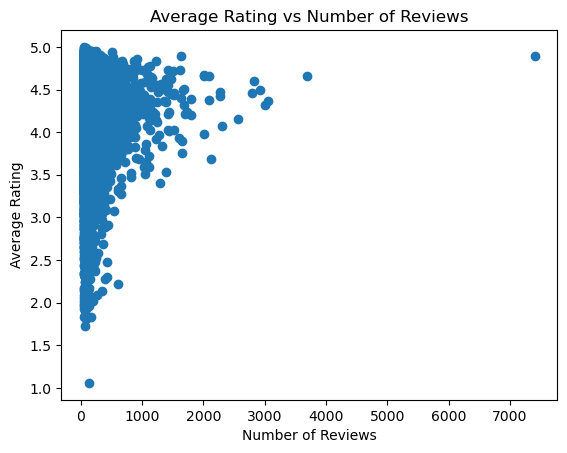

In [ ]:
# We want to see if number of review correlates with average ratings

# --- Data ---
average_rating_df = (
    sports_df_clean  
    .groupBy("product_id")
    .agg(
        F.avg("star_rating_int").alias("avg_rating"),
        F.count("*").alias("num_reviews")
    )
     # avoid tiny sample noise
    .filter(F.col("num_reviews") > 50) 
)
average_rating_pd = average_rating_df.toPandas()

# --- Plot ---
plt.figure()
plt.scatter(average_rating_pd['num_reviews'], average_rating_pd['avg_rating'])
plt.xlabel('Number of Reviews')
plt.ylabel('Average Rating')
plt.title('Average Rating vs Number of Reviews')
plt.show()

In [ ]:
# We want to see it in log plot

plt.figure()
plt.scatter(average_rating_pd['num_reviews'], average_rating_pd['avg_rating'])
plt.xscale('log')
plt.xlabel('Number of Reviews (log scale)')
plt.ylabel('Average Rating')
plt.title('Average Rating vs Number of Reviews')
plt.show()

NameError: name 'average_rating_pd' is not defined

<Figure size 640x480 with 0 Axes>